In [ ]:
from __future__ import annotations

import math
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if not (ROOT / "impl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from impl.gaussian_baseline_quantizers import (
    CubicE8Quantizer,
    QuipSharpE8Quantizer,
    UniformScalarQuantizer,
    mse_to_sqnr_bits,
)
from impl.leech_lattice_vector_quantizer_gpu import DIM, LeechLatticeVectorQuantizerGpu, squared_distance

print(ROOT)


/home/diego/Documents/cvlab/llvq-paper-reproduction


In [2]:
SEED = 0
N_SAMPLES = 8

# Cumulative Leech ball cutoffs. m=51 reaches 3.0 bits/dim.
SHELL_CUTOFFS = [2, 3, 4, 5, 6, 8, 10, 13, 16, 20, 24, 30]

# Baseline rates. Integer bits keep the simple baselines honest and fast.
BASELINE_RATES = [1.0, 2.0, 3.0]

# Idealistic Gaussian-source scaling matches source power E||w||^2 = DIM
# to the average squared norm of the finite Leech ball codebook.
GAUSSIAN_SOURCE_VARIANCE = 1.0

rng = np.random.default_rng(SEED)
samples = rng.normal(0.0, 1.0, size=(N_SAMPLES, DIM))
samples.shape


(8, 24)

In [ ]:
def benchmark_llvq(max_shell):
    q = LeechLatticeVectorQuantizerGpu(max_shell=max_shell, verbose=True)
    w = samples[0]

    weighted_norm2 = sum(2.0 * shell * count for shell, count in q.shell_counts.items())
    average_codebook_norm2 = weighted_norm2 / q.total_count
    beta = math.sqrt(DIM * GAUSSIAN_SOURCE_VARIANCE / average_codebook_norm2)

    start = time.perf_counter()
    idx = q.quantize(w)
    quantize_seconds = time.perf_counter() - start
    ranked = q.unrank(idx)

    start = time.perf_counter()
    integer_representative = q.dequantize_lattice(idx)
    dequantize_lattice_seconds = time.perf_counter() - start

    start = time.perf_counter()
    base_reconstruction = np.array(q.dequantize(idx), dtype=float)
    scaled_reconstruction = beta * base_reconstruction
    dequantize_seconds = time.perf_counter() - start

    residual = w - np.array(scaled_reconstruction, dtype=float)
    block_mse = float(np.mean(residual ** 2))
    block_rmse = float(np.sqrt(block_mse))
    residual_mean = float(np.mean(residual))
    residual_std = float(np.std(residual, ddof=1))
    abs_error_mean = float(np.mean(np.abs(residual)))
    abs_error_std = float(np.std(np.abs(residual), ddof=1))

    print("input:", np.round(w, 4))
    print("index:", idx)
    print("address:", ranked)
    print("integer representative:", integer_representative)
    print(f"beta: {beta:.6f}")
    print("base reconstruction:", np.round(base_reconstruction, 4))
    print("gaussian-scaled reconstruction:", np.round(scaled_reconstruction, 4))
    print("residual:", np.round(residual, 4))
    print(f"block MSE: {block_mse:.6f}")
    print(f"block RMSE: {block_rmse:.6f}")
    print(f"residual mean: {residual_mean:.6f}")
    print(f"residual std: {residual_std:.6f}")
    print(f"absolute error mean: {abs_error_mean:.6f}")
    print(f"absolute error std: {abs_error_std:.6f}")
    print(f"quantize time: {quantize_seconds:.6f}s")
    print(f"dequantize_lattice time: {dequantize_lattice_seconds:.6f}s")
    print(f"dequantize time: {dequantize_seconds:.6f}s")

    return {
        "block_mse": block_mse,
        "block_rmse": block_rmse,
        "residual_mean": residual_mean,
        "residual_std": residual_std,
        "absolute_error_mean": abs_error_mean,
        "absolute_error_std": abs_error_std,
        "quantize_seconds": quantize_seconds,
        "dequantize_lattice_seconds": dequantize_lattice_seconds,
        "dequantize_seconds": dequantize_seconds,
    }


In [4]:
results = {}


for max_shell in SHELL_CUTOFFS:
    print(f"\n=== max_shell={max_shell} ===")
    benchmark_llvq(max_shell)

    results[max_shell] = benchmark_llvq(max_shell)



=== max_shell=2 ===
loaded cached class leaders for shell m=2: 3 classes in 0.000s
input: [ 0.1257 -0.1321  0.6404  0.1049 -0.5357  0.3616  1.304   0.9471 -0.7037
 -1.2654 -0.6233  0.0413 -2.325  -0.2188 -1.2459 -0.7323 -0.5443 -0.3163
  0.4116  1.0425 -0.1285  1.3665 -0.6652  0.3515]
index: 126660
address: RankedCodeword(global_index=126660, shell=2, shell_local_index=126660, class_index=1, class_local_index=29508, class_offset=97152, leader=ClassLeader(shell=2, parity='odd', count=98304, mult_abs8=0, mult_abs6=0, mult_abs5=0, mult_abs4=0, mult_abs3=1, mult_abs2=0, mult_abs1=23, mult_abs0=0, extra_multiplicities=()))
integer representative: (1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, -1, -3, -1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1)
beta: 2.449490
base reconstruction: [ 0.3536 -0.3536  0.3536  0.3536 -0.3536 -0.3536  0.3536  0.3536 -0.3536
 -0.3536  0.3536 -0.3536 -1.0607 -0.3536 -0.3536 -0.3536 -0.3536 -0.3536
  0.3536  0.3536  0.3536  0.3536 -0.3536  0.3536]
gaussian-scaled reconstruction:

input: [ 0.1257 -0.1321  0.6404  0.1049 -0.5357  0.3616  1.304   0.9471 -0.7037
 -1.2654 -0.6233  0.0413 -2.325  -0.2188 -1.2459 -0.7323 -0.5443 -0.3163
  0.4116  1.0425 -0.1285  1.3665 -0.6652  0.3515]
index: 126660
address: RankedCodeword(global_index=126660, shell=2, shell_local_index=126660, class_index=1, class_local_index=29508, class_offset=97152, leader=ClassLeader(shell=2, parity='odd', count=98304, mult_abs8=0, mult_abs6=0, mult_abs5=0, mult_abs4=0, mult_abs3=1, mult_abs2=0, mult_abs1=23, mult_abs0=0, extra_multiplicities=()))
integer representative: (1, -1, 1, 1, -1, -1, 1, 1, -1, -1, 1, -1, -3, -1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1)
beta: 2.449490
base reconstruction: [ 0.3536 -0.3536  0.3536  0.3536 -0.3536 -0.3536  0.3536  0.3536 -0.3536
 -0.3536  0.3536 -0.3536 -1.0607 -0.3536 -0.3536 -0.3536 -0.3536 -0.3536
  0.3536  0.3536  0.3536  0.3536 -0.3536  0.3536]
gaussian-scaled reconstruction: [ 0.866  -0.866   0.866   0.866  -0.866  -0.866   0.866   0.866  -0.866
 -0.866   0

KeyboardInterrupt: 

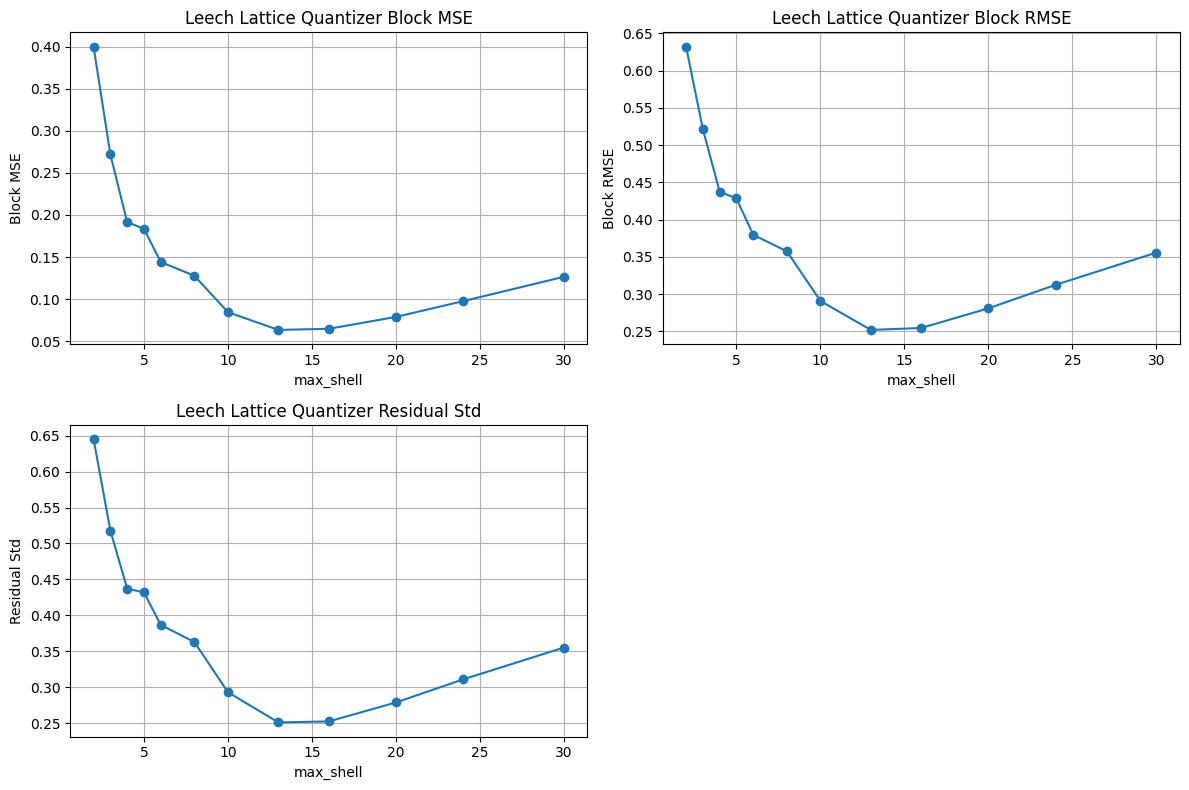

In [ ]:
# Plot results
shells = np.array(SHELL_CUTOFFS)
mse = np.array([results[shell]["block_mse"] for shell in shells])
rmse = np.array([results[shell]["block_rmse"] for shell in shells])
residual_mean = np.array([results[shell]["residual_mean"] for shell in shells])
residual_std = np.array([results[shell]["residual_std"] for shell in shells])
abs_error_mean = np.array([results[shell]["absolute_error_mean"] for shell in shells])
abs_error_std = np.array([results[shell]["absolute_error_std"] for shell in shells])

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(shells, mse, marker="o")

plt.xlabel("max_shell")
plt.ylabel("Block MSE")
plt.title("Leech Lattice Quantizer Block MSE")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(shells, rmse, marker="o")
plt.xlabel("max_shell")
plt.ylabel("Block RMSE")
plt.title("Leech Lattice Quantizer Block RMSE")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(shells, residual_std, marker="o")
plt.xlabel("max_shell")
plt.ylabel("Residual Std")
plt.title("Leech Lattice Quantizer Residual Std")
plt.grid(True)

plt.tight_layout()